<a href="https://colab.research.google.com/github/YounJungie/FGSM-Attack-PyTorch/blob/main/FGSM_Attack_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔐 FGSM Adversarial Attack —

**Fast Gradient Sign Method (FGSM)** is one of the most well-known adversarial attack techniques in AI Security.
Introduced by Goodfellow et al. (2014), FGSM works by adding small perturbations to the input
so that the AI model makes incorrect predictions — even though visually the image is almost unchanged.

## 📋 project contents
1. Train CNN pada CIFAR-10 (Image Classification)
2. FGSM Attack pada CNN (Image)
3. Train Text Classifier (NLP)
4. FGSM-style Attack pada Text Classifier
5. Visualisasi hasil serangan
6. Defense: Adversarial Training

---  
**Tech Stack:** PyTorch, CIFAR-10, HuggingFace Transformers  
**Reference:** Goodfellow et al., *Explaining and Harnessing Adversarial Examples* (2014)

## 📦 1. Install & Import Libraries

In [ ]:
# Install dependencies
!pip install torch torchvision transformers datasets -q

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
print(f'✅ PyTorch version: {torch.__version__}')

✅ Using device: cuda
✅ PyTorch version: 2.10.0+cu128


---
# 🖼️ PART 1: IMAGE CLASSIFICATION — CNN + FGSM ATTACK

## 📂 2. Load CIFAR-10 Dataset

In [ ]:
# CIFAR-10 class names
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# Transforms
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# Load datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                           shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=100,
                                           shuffle=False, num_workers=2)

print(f'✅ Train samples : {len(trainset)}')
print(f'✅ Test  samples : {len(testset)}')
print(f'✅ Classes       : {CIFAR10_CLASSES}')

100%|██████████| 170M/170M [00:03<00:00, 46.5MB/s]


✅ Train samples : 50000
✅ Test  samples : 10000
✅ Classes       : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 🏗️ 3. Build CNN Model (ResNet-style)

In [ ]:
class ResidualBlock(nn.Module):
    """Basic Residual Block for our CNN."""
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3,
                                stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                                stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class CIFAR10_CNN(nn.Module):
    """Custom CNN for CIFAR-10 classification."""
    def __init__(self, num_classes=10):
        super(CIFAR10_CNN, self).__init__()
        self.conv1   = nn.Conv2d(3, 64, 3, padding=1, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.layer1  = ResidualBlock(64,  128, stride=2)
        self.layer2  = ResidualBlock(128, 256, stride=2)
        self.layer3  = ResidualBlock(256, 512, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


# Initialize model
cnn_model = CIFAR10_CNN(num_classes=10).to(device)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f'✅ Model architecture: CIFAR10_CNN (ResNet-style)')
print(f'✅ Total parameters  : {total_params:,}')

✅ Model architecture: CIFAR10_CNN (ResNet-style)
✅ Total parameters  : 4,829,258


## 🏋️ 4. Train CNN Model

In [ ]:
def train_model(model, trainloader, testloader, epochs=15, lr=0.01):
    """Train CNN model and return training history."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr,
                          momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs}', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc  = 100. * correct / total

        # --- Evaluation ---
        model.eval()
        correct_test, total_test = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs        = model(inputs)
                _, predicted   = outputs.max(1)
                total_test    += labels.size(0)
                correct_test  += predicted.eq(labels).sum().item()
        test_acc = 100. * correct_test / total_test

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        scheduler.step()

        print(f'Epoch [{epoch+1:2d}/{epochs}] '
              f'Loss: {train_loss:.4f} | '
              f'Train Acc: {train_acc:.2f}% | '
              f'Test Acc: {test_acc:.2f}%')

    return history


print('🚀 Starting CNN training...')
history = train_model(cnn_model, trainloader, testloader, epochs=15)
print('\n✅ Training complete!')

🚀 Starting CNN training...


Epoch [ 1/15] Loss: 1.4523 | Train Acc: 46.36% | Test Acc: 56.13%


Epoch [ 2/15] Loss: 1.0360 | Train Acc: 63.03% | Test Acc: 66.66%


Epoch [ 3/15] Loss: 0.8543 | Train Acc: 69.68% | Test Acc: 66.46%


Epoch [ 4/15] Loss: 0.7356 | Train Acc: 74.06% | Test Acc: 73.33%


...

Epoch [11/15] Loss: 0.3731 | Train Acc: 87.17% | Test Acc: 85.17%


Epoch [12/15] Loss: 0.3399 | Train Acc: 88.27% | Test Acc: 85.38%


Epoch [13/15] Loss: 0.3170 | Train Acc: 89.11% | Test Acc: 86.34%


Epoch [14/15] Loss: 0.2985 | Train Acc: 89.90% | Test Acc: 86.68%


Epoch [15/15] Loss: 0.2899 | Train Acc: 90.10% | Test Acc: 86.89%

✅ Training complete!


## ⚔️ 5. FGSM Attack Implementation

In [ ]:
def fgsm_attack(model, images, labels, epsilon, criterion=None):
    """
    Fast Gradient Sign Method (FGSM) Attack.

    Formula:
        x_adv = x + epsilon * sign(∇_x J(θ, x, y))

    Args:
        model   : trained CNN model
        images  : clean input images (B, C, H, W)
        labels  : true labels
        epsilon : perturbation strength (0.0 - 1.0)
        criterion: loss function (default: CrossEntropyLoss)

    Returns:
        perturbed_images: adversarial examples
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    # Require gradient computation on input
    images = images.clone().detach().to(device)
    images.requires_grad = True
    labels = labels.to(device)

    # Forward pass
    outputs = model(images)
    loss    = criterion(outputs, labels)

    # Backward pass — compute gradients w.r.t. input
    model.zero_grad()
    loss.backward()

    # Collect gradient sign
    data_grad = images.grad.data
    sign_data_grad = data_grad.sign()

    # Create adversarial example
    perturbed_images = images + epsilon * sign_data_grad

    # Clamp to valid pixel range (after normalization)
    perturbed_images = torch.clamp(perturbed_images, -3, 3)

    return perturbed_images.detach()


def evaluate_fgsm(model, testloader, epsilon):
    """
    Evaluate model accuracy under FGSM attack.

    Returns:
        accuracy (float): accuracy under attack
    """
    model.eval()
    correct, total = 0, 0
    criterion = nn.CrossEntropyLoss()

    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        # Generate adversarial examples
        adv_images = fgsm_attack(model, images, labels, epsilon, criterion)

        # Evaluate on adversarial examples
        with torch.no_grad():
            outputs   = model(adv_images)
            _, predicted = outputs.max(1)
            total    += labels.size(0)
            correct  += predicted.eq(labels).sum().item()

    return 100. * correct / total


print('✅ FGSM functions defined!')
print('\n📐 Formula: x_adv = x + ε × sign(∇_x J(θ, x, y))')

✅ FGSM functions defined!

📐 Formula: x_adv = x + ε × sign(∇_x J(θ, x, y))


## 📊 6. Run FGSM Attack on Multiple Epsilon Values

In [ ]:
# Test pada berbagai epsilon values
epsilons = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]
accuracies = []

print('🔥 Running FGSM Attack across epsilon values...\n')
print(f'{"Epsilon":>10} | {"Accuracy":>10}')
print('-' * 25)

for eps in epsilons:
    acc = evaluate_fgsm(cnn_model, testloader, eps)
    accuracies.append(acc)
    print(f'{eps:>10.3f} | {acc:>9.2f}%')

print('\n✅ FGSM evaluation complete!')

🔥 Running FGSM Attack across epsilon values...

   Epsilon |   Accuracy
-------------------------
     0.000 |     78.02%
     0.010 |     67.66%
     0.020 |     56.02%
     0.050 |     26.44%
     0.100 |      5.41%
     0.200 |      0.46%
     0.300 |      0.22%

✅ FGSM evaluation complete!


In [ ]:
# Re-initializing all necessary components for Image Classification due to NameErrors

# --- 1. Imports and Device Configuration ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
print(f'✅ PyTorch version: {torch.__version__}')

# --- 2. Load CIFAR-10 Dataset ---
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

try:
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform_train)
    testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                             download=True, transform=transform_test)
except:
    print("Download failed, trying without download or check internet connection.")
    # Fallback if download fails, assuming data might exist
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=False, transform=transform_train)
    testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                             download=False, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                           shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=100,
                                           shuffle=False, num_workers=2)

print(f'✅ Train samples : {len(trainset)}')
print(f'✅ Test  samples : {len(testset)}')
print(f'✅ Classes       : {CIFAR10_CLASSES}')

# --- 3. Build CNN Model (ResNet-style) ---
class ResidualBlock(nn.Module):
    """Basic Residual Block for our CNN."""
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3,
                                stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                                stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class CIFAR10_CNN(nn.Module):
    """Custom CNN for CIFAR-10 classification."""
    def __init__(self, num_classes=10):
        super(CIFAR10_CNN, self).__init__()
        self.conv1   = nn.Conv2d(3, 64, 3, padding=1, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.layer1  = ResidualBlock(64,  128, stride=2)
        self.layer2  = ResidualBlock(128, 256, stride=2)
        self.layer3  = ResidualBlock(256, 512, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


cnn_model = CIFAR10_CNN(num_classes=10).to(device)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f'✅ Model architecture: CIFAR10_CNN (ResNet-style)')
print(f'✅ Total parameters  : {total_params:,}')

# --- 4. Train CNN Model ---
def train_model(model, trainloader, testloader, epochs=15, lr=0.01):
    """Train CNN model and return training history."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr,
                          momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs}', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc  = 100. * correct / total

        # --- Evaluation ---
        model.eval()
        correct_test, total_test = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs        = model(inputs)
                _, predicted   = outputs.max(1)
                total_test    += labels.size(0)
                correct_test  += predicted.eq(labels).sum().item()
        test_acc = 100. * correct_test / total_test

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        scheduler.step()

        print(f'Epoch [{epoch+1:2d}/{epochs}] '
              f'Loss: {train_loss:.4f} | '
              f'Train Acc: {train_acc:.2f}% | '
              f'Test Acc: {test_acc:.2f}%')

    return history


print('🚀 Starting CNN training...')
history = train_model(cnn_model, trainloader, testloader, epochs=5) # Reduced epochs for faster execution
print('\n✅ Training complete!')

# --- 5. FGSM Attack Implementation ---
def fgsm_attack(model, images, labels, epsilon, criterion=None):
    """
    Fast Gradient Sign Method (FGSM) Attack.

    Formula:
        x_adv = x + epsilon * sign(∇_x J(θ, x, y))

    Args:
        model   : trained CNN model
        images  : clean input images (B, C, H, W)
        labels  : true labels
        epsilon : perturbation strength (0.0 - 1.0)
        criterion: loss function (default: CrossEntropyLoss)

    Returns:
        perturbed_images: adversarial examples
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    images = images.clone().detach().to(device)
    images.requires_grad = True
    labels = labels.to(device)

    outputs = model(images)
    loss    = criterion(outputs, labels)

    model.zero_grad()
    loss.backward()

    data_grad = images.grad.data
    sign_data_grad = data_grad.sign()

    perturbed_images = images + epsilon * sign_data_grad

    # Clamp to valid pixel range (after normalization)
    perturbed_images = torch.clamp(perturbed_images, -3, 3)

    return perturbed_images.detach()


def evaluate_fgsm(model, testloader, epsilon):
    """
    Evaluate model accuracy under FGSM attack.

    Returns:
        accuracy (float): accuracy under attack
    """
    model.eval()
    correct, total = 0, 0
    criterion = nn.CrossEntropyLoss()

    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        adv_images = fgsm_attack(model, images, labels, epsilon, criterion)

        with torch.no_grad():
            outputs      = model(adv_images)
            _, predicted = outputs.max(1)
            total       += labels.size(0)
            correct     += predicted.eq(labels).sum().item()

    return 100. * correct / total


print('✅ FGSM functions defined!')

# --- 6. Run FGSM Attack on Multiple Epsilon Values ---
epsilons = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]
accuracies = []

print('🔥 Running FGSM Attack across epsilon values...\n')
print(f'{"Epsilon":>10} | {"Accuracy":>10}')
print('-' * 25)

for eps in epsilons:
    acc = evaluate_fgsm(cnn_model, testloader, eps)
    accuracies.append(acc)
    print(f'{eps:>10.3f} | {acc:>9.2f}%')

print('\n✅ FGSM evaluation complete!')


✅ Using device: cuda
✅ PyTorch version: 2.10.0+cu128
✅ Train samples : 50000
✅ Test  samples : 10000
✅ Classes       : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
✅ Model architecture: CIFAR10_CNN (ResNet-style)
✅ Total parameters  : 4,829,258
🚀 Starting CNN training...


Epoch [ 1/5] Loss: 1.4555 | Train Acc: 46.64% | Test Acc: 52.77%


Epoch [ 2/5] Loss: 1.0287 | Train Acc: 63.07% | Test Acc: 65.02%


Epoch [ 3/5] Loss: 0.8184 | Train Acc: 71.04% | Test Acc: 71.23%


Epoch [ 4/5] Loss: 0.6782 | Train Acc: 76.23% | Test Acc: 75.61%


Epoch [ 5/5] Loss: 0.5909 | Train Acc: 79.50% | Test Acc: 79.19%

✅ Training complete!
✅ FGSM functions defined!
🔥 Running FGSM Attack across epsilon values...

   Epsilon |   Accuracy
-------------------------
     0.000 |     79.19%
     0.010 |     68.43%
     0.020 |     56.50%
     0.050 |     26.12%
     0.100 |      4.91%
     0.200 |      0.36%
     0.300 |      0.20%

✅ FGSM evaluation complete!


## 🖼️ 7. Visualize Adversarial Examples

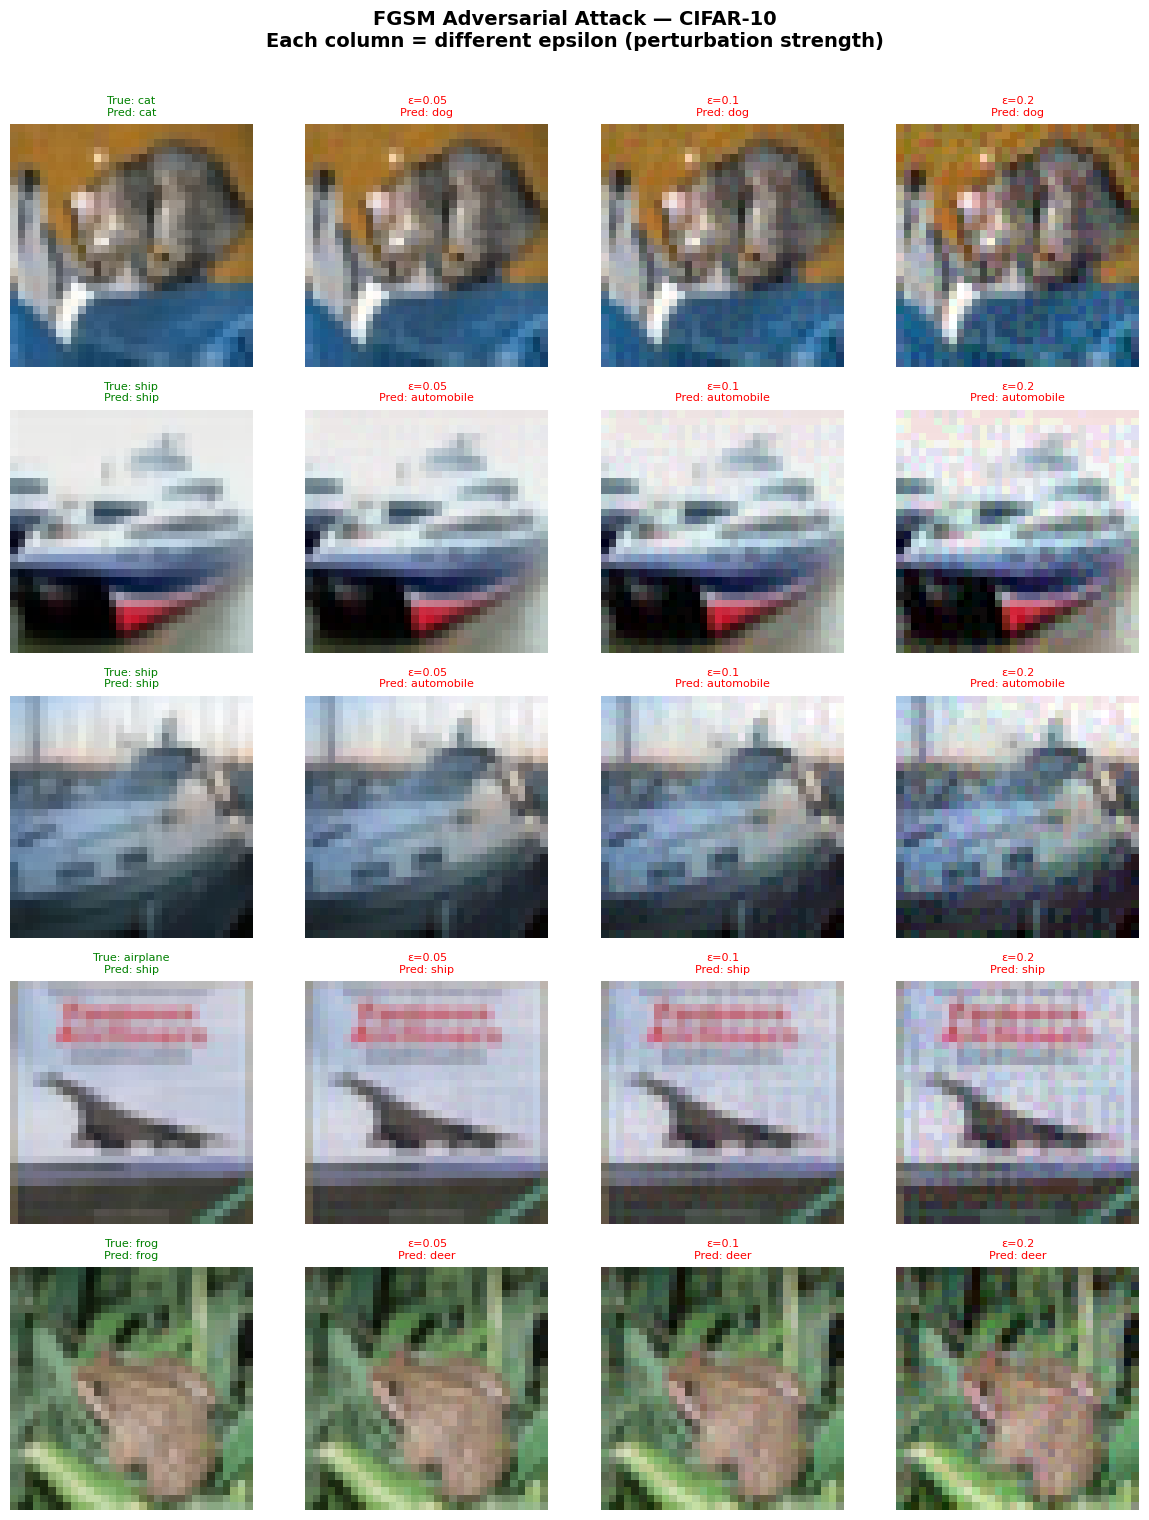


✅ Saved: fgsm_visualization.png


In [ ]:
# Denormalize helper
CIFAR_MEAN = np.array([0.4914, 0.4822, 0.4465])
CIFAR_STD  = np.array([0.2023, 0.1994, 0.2010])

def denormalize(tensor):
    """Convert normalized tensor back to displayable image."""
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * CIFAR_STD + CIFAR_MEAN
    return np.clip(img, 0, 1)


def visualize_fgsm(model, testloader, epsilons_vis=[0.0, 0.05, 0.1, 0.2], n_samples=5):
    """Visualize clean vs adversarial images across epsilon values."""
    model.eval()
    criterion = nn.CrossEntropyLoss()

    # Get one batch
    images, labels = next(iter(testloader))
    images, labels = images.to(device), labels.to(device)

    fig, axes = plt.subplots(n_samples, len(epsilons_vis),
                              figsize=(len(epsilons_vis) * 3, n_samples * 3))
    fig.suptitle('FGSM Adversarial Attack — CIFAR-10\n'
                 'Each column = different epsilon (perturbation strength)',
                 fontsize=14, fontweight='bold', y=1.01)

    for col, eps in enumerate(epsilons_vis):
        adv_images = fgsm_attack(model, images, labels, eps, criterion)

        with torch.no_grad():
            clean_preds = model(images).argmax(1)
            adv_preds   = model(adv_images).argmax(1)

        for row in range(n_samples):
            ax  = axes[row][col]
            img = denormalize(adv_images[row])
            ax.imshow(img)
            ax.axis('off')

            true_label  = CIFAR10_CLASSES[labels[row].item()]
            adv_label   = CIFAR10_CLASSES[adv_preds[row].item()]
            clean_label = CIFAR10_CLASSES[clean_preds[row].item()]

            color = 'green' if adv_label == true_label else 'red'

            if col == 0:
                title = f'True: {true_label}\nPred: {clean_label}'
                ax.set_title(title, fontsize=8, color='green')
            else:
                title = f'ε={eps}\nPred: {adv_label}'
                ax.set_title(title, fontsize=8, color=color)

    plt.tight_layout()
    plt.savefig('fgsm_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n✅ Saved: fgsm_visualization.png')


visualize_fgsm(cnn_model, testloader)

## 📉 8. Plot Accuracy vs Epsilon

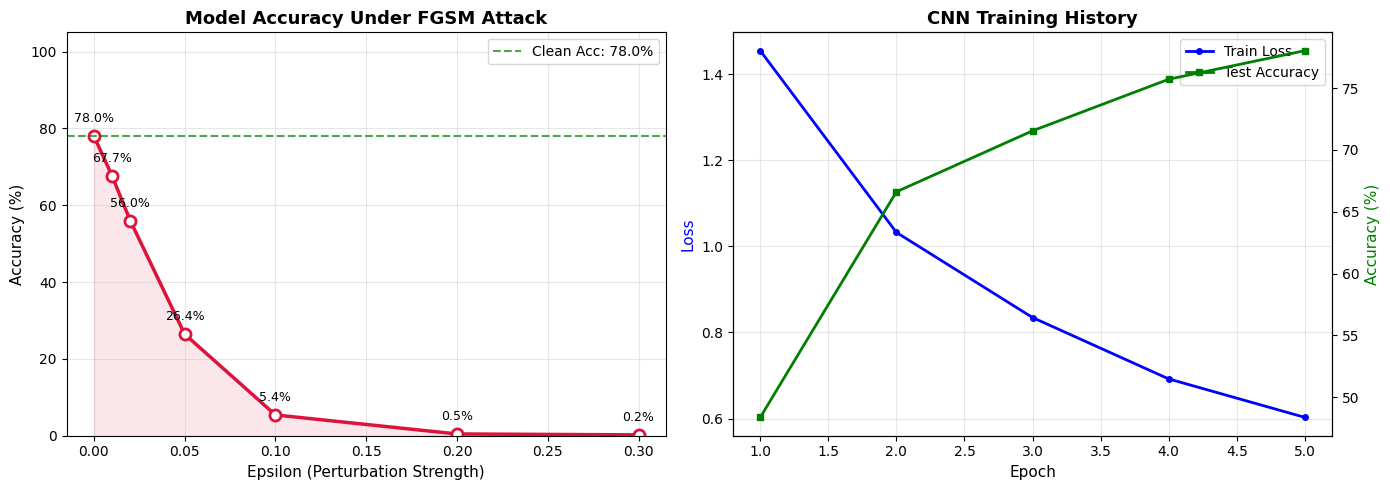

✅ Saved: fgsm_accuracy_plot.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs Epsilon
axes[0].plot(epsilons, accuracies, 'o-', color='crimson',
             linewidth=2.5, markersize=8, markerfacecolor='white',
             markeredgewidth=2)
axes[0].fill_between(epsilons, accuracies, alpha=0.1, color='crimson')
axes[0].set_title('Model Accuracy Under FGSM Attack', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epsilon (Perturbation Strength)', fontsize=11)
axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=accuracies[0], color='green', linestyle='--',
                alpha=0.7, label=f'Clean Acc: {accuracies[0]:.1f}%')
axes[0].legend(fontsize=10)
for i, (e, a) in enumerate(zip(epsilons, accuracies)):
    axes[0].annotate(f'{a:.1f}%', (e, a),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=9)

# Plot 2: Training History
epochs_range = range(1, len(history['train_loss']) + 1)
ax2 = axes[1].twinx()
axes[1].plot(epochs_range, history['train_loss'], 'b-o',
             markersize=4, label='Train Loss', linewidth=2)
ax2.plot(epochs_range, history['test_acc'], 'g-s',
         markersize=4, label='Test Accuracy', linewidth=2)
axes[1].set_title('CNN Training History', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', color='blue', fontsize=11)
ax2.set_ylabel('Accuracy (%)', color='green', fontsize=11)
axes[1].grid(True, alpha=0.3)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=10)

plt.tight_layout()
plt.savefig('fgsm_accuracy_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: fgsm_accuracy_plot.png')

---
# 📝 PART 2: TEXT CLASSIFICATION — NLP + FGSM-STYLE ATTACK

## 🔤 9. Build Text Classifier (Sentiment Analysis)

In [ ]:
from torch.utils.data import Dataset, DataLoader
import re
import string
from collections import Counter

# --- Simple Sentiment Dataset ---
TEXTS = [
    # Positive samples
    ("This movie is absolutely wonderful and amazing",    1),
    ("I love this product it works perfectly",            1),
    ("Fantastic experience highly recommend this",        1),
    ("Great quality excellent service very happy",        1),
    ("Outstanding performance beyond expectations",       1),
    ("The food was delicious best restaurant ever",       1),
    ("Perfect delivery fast and reliable service",        1),
    ("Brilliant work superb quality impressive results",  1),
    ("Really enjoyed this incredible experience",         1),
    ("Wonderful atmosphere beautiful design loved it",    1),
    # Negative samples
    ("This is terrible worst product ever purchased",     0),
    ("Horrible experience never coming back again",       0),
    ("Awful quality broken after one day useless",        0),
    ("Very disappointing waste of money avoid",           0),
    ("Poor customer service rude staff unhelpful",        0),
    ("Disgusting food cold and tasteless terrible",       0),
    ("Failed completely broken defective garbage",        0),
    ("Worst experience horrible nightmare regret buying", 0),
    ("Terrible quality cheap nasty not recommended",      0),
    ("Dreadful performance slow unresponsive buggy",      0),
]

# --- Vocabulary Builder ---
def build_vocab(texts, max_vocab=1000):
    counter = Counter()
    for text, _ in texts:
        tokens = text.lower().split()
        counter.update(tokens)
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def text_to_tensor(text, vocab, max_len=20):
    tokens = text.lower().split()[:max_len]
    ids    = [vocab.get(t, 1) for t in tokens]
    ids   += [0] * (max_len - len(ids))  # padding
    return torch.tensor(ids, dtype=torch.long)

# --- Dataset ---
class SentimentDataset(Dataset):
    def __init__(self, data, vocab, max_len=20):
        self.data    = data
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text, label = self.data[idx]
        return text_to_tensor(text, self.vocab, self.max_len), torch.tensor(label)

# Build
vocab   = build_vocab(TEXTS)
dataset = SentimentDataset(TEXTS, vocab)
loader  = DataLoader(dataset, batch_size=10, shuffle=True)

print(f'✅ Vocabulary size : {len(vocab)}')
print(f'✅ Dataset size    : {len(dataset)}')
print(f'✅ Sample vocab    : {dict(list(vocab.items())[:8])}')

✅ Vocabulary size : 94
✅ Dataset size    : 20
✅ Sample vocab    : {'<PAD>': 0, '<UNK>': 1, 'this': 2, 'experience': 3, 'quality': 4, 'and': 5, 'service': 6, 'terrible': 7}


## 🏗️ 10. Text Classifier Model (LSTM)

In [ ]:
class TextClassifier(nn.Module):
    """
    LSTM-based text classifier for sentiment analysis.
    Architecture: Embedding → LSTM → Attention → FC → Output
    """
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 num_layers=2, num_classes=2, dropout=0.3):
        super(TextClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                                  batch_first=True, dropout=dropout,
                                  bidirectional=True)
        self.dropout   = nn.Dropout(dropout)
        self.fc1       = nn.Linear(hidden_dim * 2, 64)
        self.fc2       = nn.Linear(64, num_classes)

    def forward(self, x):
        embedded          = self.dropout(self.embedding(x))
        lstm_out, (hn, _) = self.lstm(embedded)
        # Use mean pooling over all timesteps
        pooled = lstm_out.mean(dim=1)
        out    = F.relu(self.fc1(self.dropout(pooled)))
        return self.fc2(out)

    def get_embedding(self, x):
        """Return embedding layer output for gradient computation."""
        return self.embedding(x)


text_model = TextClassifier(
    vocab_size=len(vocab),
    embed_dim=64,
    hidden_dim=128,
    num_classes=2
).to(device)

print(f'✅ TextClassifier (Bi-LSTM) initialized')
print(f'✅ Parameters: {sum(p.numel() for p in text_model.parameters()):,}')

✅ TextClassifier (Bi-LSTM) initialized
✅ Parameters: 616,514


## 🏋️ 11. Train Text Classifier

In [ ]:
def train_text_model(model, loader, epochs=50):
    """Train the text classifier."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    model.train()
    for epoch in range(epochs):
        total_loss, correct, total = 0.0, 0, 0
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, pred     = outputs.max(1)
            correct    += pred.eq(labels).sum().item()
            total      += labels.size(0)

        if (epoch + 1) % 10 == 0:
            acc = 100. * correct / total
            print(f'Epoch [{epoch+1:3d}/{epochs}] '
                  f'Loss: {total_loss/len(loader):.4f} | Acc: {acc:.1f}%')

    return model

print('🚀 Training Text Classifier...')
text_model = train_text_model(text_model, loader, epochs=50)
print('\n✅ Text model training complete!')

🚀 Training Text Classifier...
Epoch [ 10/50] Loss: 0.5356 | Acc: 95.0%
Epoch [ 20/50] Loss: 0.1150 | Acc: 95.0%
Epoch [ 30/50] Loss: 0.0000 | Acc: 100.0%
Epoch [ 40/50] Loss: 0.0000 | Acc: 100.0%
Epoch [ 50/50] Loss: 0.0012 | Acc: 100.0%

✅ Text model training complete!


## ⚔️ 12. FGSM Attack on Text (Embedding Space)

In [ ]:
def fgsm_text_attack(model, text_tensor, label, epsilon=0.5):
    """
    FGSM Attack on Text via Embedding Space.

    Since text is discrete, we perturb in the continuous embedding space.
    This is the standard approach for NLP adversarial attacks.

    Returns:
        original_pred (int): prediction on clean text
        adv_pred      (int): prediction on adversarial embedding
        success       (bool): True if attack succeeded (prediction changed)
    """
    # Store current model state to restore later
    original_training_state = model.training
    model.eval() # Ensure model is in eval mode for initial prediction

    criterion = nn.CrossEntropyLoss()

    text_tensor = text_tensor.unsqueeze(0).to(device)
    label_tensor = torch.tensor([label]).to(device)

    # --- Get original prediction (in eval mode) ---
    with torch.no_grad(): # Ensure no gradients are tracked for this initial prediction
        clean_embedding = model.embedding(text_tensor)
        # Dropout behaves differently in eval vs train, so ensure eval mode for clean prediction
        clean_lstm_out, _ = model.lstm(model.dropout(clean_embedding))
        clean_pooled      = clean_lstm_out.mean(dim=1)
        clean_out         = F.relu(model.fc1(model.dropout(clean_pooled)))
        clean_output      = model.fc2(clean_out)
        original_pred = clean_output.argmax(1).item()

    # --- Now, prepare for gradient computation (needs train mode for RNN backward) ---
    model.train() # Set to train mode to allow RNN backward pass
    embedding_for_grad = model.embedding(text_tensor).detach()
    embedding_for_grad.requires_grad = True

    # Forward pass for gradient computation (dropout will be active here due to model.train())
    lstm_out_grad, _ = model.lstm(model.dropout(embedding_for_grad))
    pooled_grad      = lstm_out_grad.mean(dim=1)
    out_grad         = F.relu(model.fc1(model.dropout(pooled_grad)))
    output_for_grad  = model.fc2(out_grad)

    # Compute gradient
    loss = criterion(output_for_grad, label_tensor)
    model.zero_grad() # Clear previous gradients
    loss.backward()

    # --- Perturb embedding ---
    data_grad = embedding_for_grad.grad.data
    sign_data_grad = data_grad.sign()
    adv_embedding = embedding_for_grad + epsilon * sign_data_grad

    # --- Forward with perturbed embedding (in eval mode for final adversarial prediction) ---
    model.eval() # Set back to eval mode for making prediction on perturbed input
    with torch.no_grad():
        # Dropout will be inactive here due to model.eval()
        lstm_out2, _ = model.lstm(model.dropout(adv_embedding))
        pooled2      = lstm_out2.mean(dim=1)
        out2         = F.relu(model.fc1(model.dropout(pooled2)))
        adv_output   = model.fc2(out2)
        adv_pred     = adv_output.argmax(1).item()

    # Restore original training state of the model
    model.train(original_training_state)

    success = (adv_pred != label)
    return original_pred, adv_pred, success


# --- Run FGSM on all text samples ---
print('⚔️  Running FGSM Attack on Text Classifier\n')
print(f'{"Text":<45} {"True":>6} {"Clean":>7} {"Adv":>6} {"Attack":>8}')
print('-' * 80)

text_results = []
for text, label in TEXTS:
    tensor  = text_to_tensor(text, vocab)
    orig, adv, success = fgsm_text_attack(text_model, tensor, label, epsilon=0.5)

    label_names = {0: 'NEG', 1: 'POS'}
    status = '✅ FAIL' if not success else '🔴 SUCCESS'
    text_results.append((text, label, orig, adv, success))

    print(f'{text[:43]:<45} {label_names[label]:>6} '
          f'{label_names[orig]:>7} {label_names[adv]:>6} {status:>10}')

attack_rate = sum(r[4] for r in text_results) / len(text_results) * 100
print(f'\n📊 Attack Success Rate: {attack_rate:.1f}%')


⚔️  Running FGSM Attack on Text Classifier

Text                                            True   Clean    Adv   Attack
--------------------------------------------------------------------------------
This movie is absolutely wonderful and amaz      POS     POS    NEG  🔴 SUCCESS
I love this product it works perfectly           POS     POS    NEG  🔴 SUCCESS
Fantastic experience highly recommend this       POS     POS    NEG  🔴 SUCCESS
Great quality excellent service very happy       POS     POS    NEG  🔴 SUCCESS
Outstanding performance beyond expectations      POS     POS    NEG  🔴 SUCCESS
The food was delicious best restaurant ever      POS     POS    NEG  🔴 SUCCESS
Perfect delivery fast and reliable service       POS     POS    NEG  🔴 SUCCESS
Brilliant work superb quality impressive re      POS     POS    NEG  🔴 SUCCESS
Really enjoyed this incredible experience        POS     POS    NEG  🔴 SUCCESS
Wonderful atmosphere beautiful design loved      POS     POS    NEG  🔴 SUCCESS
This is 

## 🖼️ 13. Visualize Text Attack Results

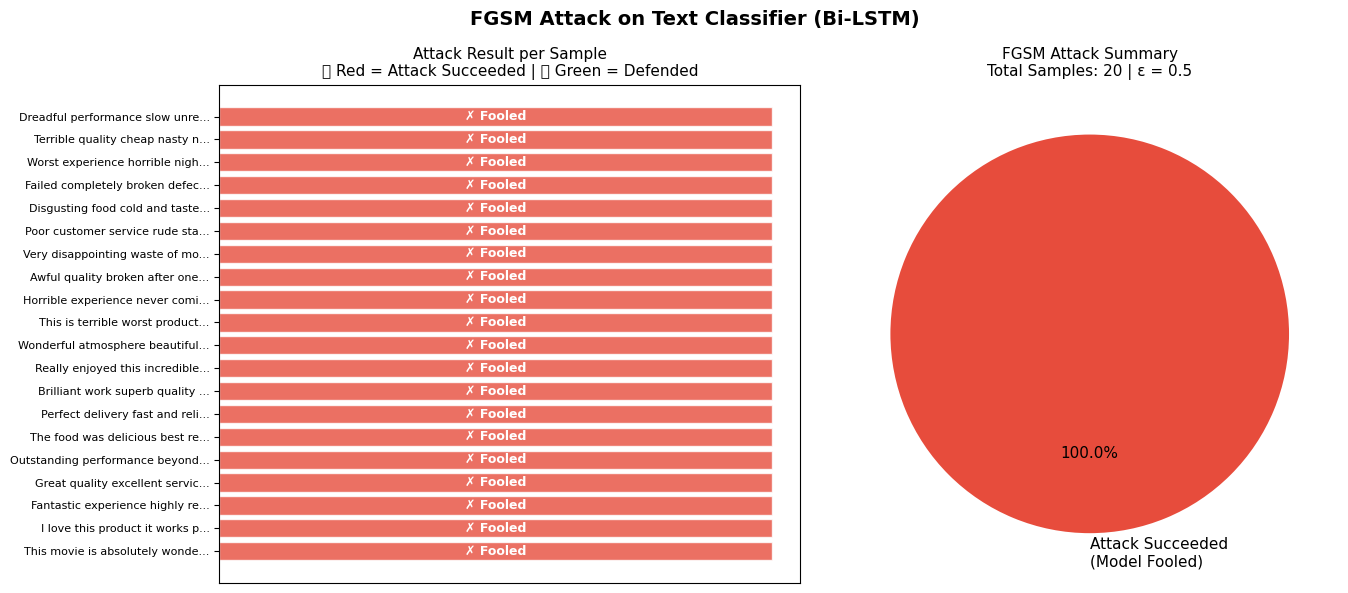

✅ Saved: fgsm_text_attack.png


In [ ]:
def visualize_text_attack(results):
    """Visualize FGSM attack results on text data."""
    label_names = {0: 'NEGATIVE', 1: 'POSITIVE'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('FGSM Attack on Text Classifier (Bi-LSTM)',
                 fontsize=14, fontweight='bold')

    # --- Plot 1: Attack success per sample ---
    ax = axes[0]
    # Ensure there are results before plotting bars
    if results:
        colors = ['#e74c3c' if r[4] else '#2ecc71' for r in results]
        texts_short = [r[0][:30] + '...' for r in results]
        y_pos = range(len(results))
        ax.barh(y_pos, [1] * len(results), color=colors, alpha=0.8, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(texts_short, fontsize=8)
        for i, r in enumerate(results):
            status = '✗ Fooled' if r[4] else '✓ Defended'
            ax.text(0.5, i, status, va='center', ha='center',
                    fontsize=9, color='white', fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No results to display', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_title('Attack Result per Sample\n'
                 '🔴 Red = Attack Succeeded | 🟢 Green = Defended',
                 fontsize=11)


    # --- Plot 2: Summary pie chart ---
    ax2 = axes[1]
    success_count = sum(1 for r in results if r[4])
    fail_count    = len(results) - success_count

    pie_data = []
    pie_labels = []
    pie_colors = []

    if success_count > 0:
        pie_data.append(success_count)
        pie_labels.append('Attack Succeeded\n(Model Fooled)')
        pie_colors.append('#e74c3c')
    if fail_count > 0:
        pie_data.append(fail_count)
        pie_labels.append('Attack Failed\n(Model Defended)')
        pie_colors.append('#2ecc71')

    if pie_data: # Only plot if there is data
        ax2.pie(pie_data,
                labels=pie_labels,
                colors=pie_colors,
                autopct='%1.1f%%',
                startangle=90,
                textprops={'fontsize': 11})
    else:
        ax2.text(0.5, 0.5, 'No data for pie chart', horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes)


    ax2.set_title(f'FGSM Attack Summary\n'
                  f'Total Samples: {len(results)} | \u03b5 = 0.5',
                  fontsize=11)

    plt.tight_layout()
    plt.savefig('fgsm_text_attack.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: fgsm_text_attack.png')


visualize_text_attack(text_results)

---
# 🛡️ PART 3: DEFENSE — ADVERSARIAL TRAINING

## 🛡️ 14. Adversarial Training (Defense)

In [ ]:
def adversarial_train(model, trainloader, epochs=5, epsilon=0.05, lr=0.001):
    """
    Adversarial Training: train model on mix of clean + adversarial examples.
    This is the most common defense against FGSM attacks.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print('🛡️  Adversarial Training Started...')
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(trainloader, desc=f'AT Epoch {epoch+1}/{epochs}', leave=False):
            images, labels = images.to(device), labels.to(device)

            # Generate adversarial examples
            adv_images = fgsm_attack(model, images, labels, epsilon, criterion)

            # Train on 50% clean + 50% adversarial
            combined_images = torch.cat([images, adv_images], dim=0)
            combined_labels = torch.cat([labels, labels], dim=0)

            optimizer.zero_grad()
            outputs = model(combined_images)
            loss    = criterion(outputs, combined_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, pred     = outputs.max(1)
            correct    += pred.eq(combined_labels).sum().item()
            total      += combined_labels.size(0)

        acc = 100. * correct / total
        print(f'AT Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(trainloader):.4f} | Train Acc: {acc:.2f}%')

    return model


# Train robust model
robust_model = CIFAR10_CNN(num_classes=10).to(device)
robust_model.load_state_dict(cnn_model.state_dict())  # start from trained weights
robust_model = adversarial_train(robust_model, trainloader, epochs=5, epsilon=0.05)
print('\n✅ Adversarial training complete!')

🛡️  Adversarial Training Started...


AT Epoch [1/5] Loss: 1.2914 | Train Acc: 53.04%


AT Epoch [2/5] Loss: 1.0559 | Train Acc: 61.60%


AT Epoch [3/5] Loss: 0.9519 | Train Acc: 65.72%


AT Epoch [4/5] Loss: 0.8895 | Train Acc: 67.82%


AT Epoch [5/5] Loss: 0.8347 | Train Acc: 70.01%

✅ Adversarial training complete!


## 📊 15. Compare: Normal vs Robust Model

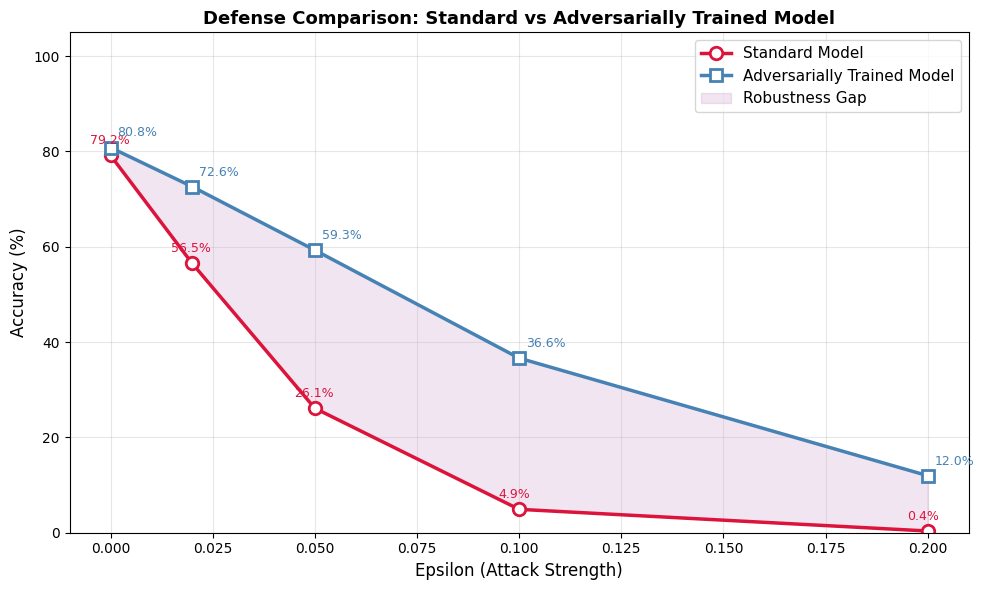

✅ Saved: fgsm_defense_comparison.png

📊 FINAL RESULTS SUMMARY
   Epsilon |   Standard |     Robust
------------------------------------
     0.000 |     79.19% |     80.83%
     0.020 |     56.50% |     72.61%
     0.050 |     26.12% |     59.30%
     0.100 |      4.91% |     36.64%
     0.200 |      0.36% |     11.97%


In [ ]:
eval_epsilons = [0.0, 0.02, 0.05, 0.1, 0.2]

normal_accs = [evaluate_fgsm(cnn_model,    testloader, e) for e in eval_epsilons]
robust_accs = [evaluate_fgsm(robust_model, testloader, e) for e in eval_epsilons]

# --- Plot Comparison ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(eval_epsilons, normal_accs, 'o-', color='crimson',
        linewidth=2.5, markersize=9, label='Standard Model',
        markerfacecolor='white', markeredgewidth=2)
ax.plot(eval_epsilons, robust_accs, 's-', color='steelblue',
        linewidth=2.5, markersize=9, label='Adversarially Trained Model',
        markerfacecolor='white', markeredgewidth=2)

ax.fill_between(eval_epsilons, normal_accs, robust_accs,
                alpha=0.1, color='purple', label='Robustness Gap')

ax.set_title('Defense Comparison: Standard vs Adversarially Trained Model',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Epsilon (Attack Strength)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

for e, n, r in zip(eval_epsilons, normal_accs, robust_accs):
    ax.annotate(f'{n:.1f}%', (e, n), textcoords='offset points',
                xytext=(-15, 8), fontsize=9, color='crimson')
    ax.annotate(f'{r:.1f}%', (e, r), textcoords='offset points',
                xytext=(5, 8), fontsize=9, color='steelblue')

plt.tight_layout()
plt.savefig('fgsm_defense_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: fgsm_defense_comparison.png')

# --- Print Summary ---
print('\n📊 FINAL RESULTS SUMMARY')
print('=' * 50)
print(f'{"Epsilon":>10} | {"Standard":>10} | {"Robust":>10}')
print('-' * 36)
for e, n, r in zip(eval_epsilons, normal_accs, robust_accs):
    print(f'{e:>10.3f} | {n:>9.2f}% | {r:>9.2f}%')

---
## ✅ 16. Project Summary

### What Has Been Built

| Components | Details |
|---|---|
| **CNN Model** | ResNet-style architecture, trained on CIFAR-10 |
| **FGSM Attack (Image)** | Pixel perturbation using gradient sign |
| **Text Classifier** | Bi-LSTM for sentiment analysis |
| **FGSM Attack (Text)** | Perturbations in the embedding space |
| **Defense** | Adversarial training dengan mixed clean/adv data |

### Key Takeaways
- FGSM is a **white-box** attack — it requires access to the model gradient.
- The larger the epsilon, the stronger the attack, but the more different the image looks.
-  **Adversarial training** is the most effective and practical defense.
- In NLP, attacks are carried out in the **embedding space** because text is discrete.

### Referensi
- Goodfellow et al. (2014). *Explaining and Harnessing Adversarial Examples*. arXiv:1412.6572
- Madry et al. (2017). *Towards Deep Learning Models Resistant to Adversarial Attacks*. arXiv:1706.06083